# Hackathon Albert 2026 — Sujet 3 : Généralisation
### Solutions complètes — Questions 1 à 14

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '../SujetsHackathon2026/Sujet3/Généralisation'
OUTPUT_DIR = '.'

ships_df      = pd.read_csv(f'{DATA_DIR}/ships_large.csv')
radio_df      = pd.read_csv(f'{DATA_DIR}/radio_signatures_large.csv')
ais_df        = pd.read_csv(f'{DATA_DIR}/ais_data_large.csv')
anomalies_df  = pd.read_csv(f'{DATA_DIR}/anomalies_large.csv')

print(f'ships      : {ships_df.shape}')
print(f'radio      : {radio_df.shape}')
print(f'ais        : {ais_df.shape}')
print(f'anomalies  : {anomalies_df.shape}')

ships      : (1000, 13)
radio      : (5000, 13)
ais        : (10000, 11)
anomalies  : (100, 7)


---
## Partie 1 — Création d'une Base de Données de Signatures Radio
### Question 1 : Agrégation des signatures radio

In [2]:
# Colonnes numériques à agréger
numeric_cols = ['frequency', 'bandwidth', 'power', 'signal_strength',
                'noise_level', 'signal_to_noise_ratio', 'location_lat', 'location_lon']

# Agrégation par navire (mmsi)
radio_profiles = radio_df.groupby('mmsi')[numeric_cols].agg(
    mean_frequency          = ('frequency',             'mean'),
    std_frequency           = ('frequency',             'std'),
    mean_bandwidth          = ('bandwidth',             'mean'),
    mean_power              = ('power',                 'mean'),
    mean_signal_strength    = ('signal_strength',       'mean'),
    mean_noise_level        = ('noise_level',           'mean'),
    mean_snr                = ('signal_to_noise_ratio', 'mean'),
    mean_lat                = ('location_lat',          'mean'),
    mean_lon                = ('location_lon',          'mean'),
    nb_signatures           = ('frequency',             'count')
).reset_index()

# Fusion avec le nom du navire
radio_profiles = radio_profiles.merge(
    ships_df[['mmsi', 'name', 'flag', 'type']],
    on='mmsi', how='left'
)

# Sauvegarde
radio_profiles.to_csv(f'{OUTPUT_DIR}/ship_radio_profiles.csv', index=False)
print(f'Profils générés : {len(radio_profiles)} navires')
print(f'Fichier sauvegardé → ship_radio_profiles.csv')
radio_profiles.head()

Profils générés : 994 navires
Fichier sauvegardé → ship_radio_profiles.csv


,mmsi,mean_frequency,std_frequency,mean_bandwidth,mean_power,mean_signal_strength,mean_noise_level,mean_snr,mean_lat,mean_lon,nb_signatures,name,flag,type
0,200698187,158.9000,1.608378,26.450000,290.666667,-74.366667,-80.883333,35.666667,-11.779233,-81.089783,6,NAVIRE-8187,USA,Fishing Vessel
1,201837657,159.2650,1.757791,22.066667,164.716667,-85.816667,-99.950000,34.733333,-25.691983,-35.933283,6,NAVIRE-7657,Marshall Islands,Fishing Vessel
2,202156040,156.7800,0.390000,31.733333,186.733333,-74.033333,-84.733333,17.400000,-28.204100,20.287167,3,NAVIRE-6040,Malta,Passenger Ship
3,203295373,158.5225,1.633429,37.950000,80.125000,-85.075000,-92.150000,25.950000,-16.789950,-45.778475,4,NAVIRE-5373,Denmark,Bulk Carrier
4,204111655,158.5420,1.896041,39.840000,271.700000,-59.240000,-93.980000,22.520000,-6.892160,-55.951260,5,NAVIRE-1655,Bahamas,Bulk Carrier



🏆 Top 5 navires — Fréquence moyenne la plus élevée

        mmsi         name       flag  mean_frequency  nb_signatures
1  211239944  NAVIRE-9944  Singapore      161.940000              1
2  604969493  NAVIRE-9493      China      161.790000              1
3  205927097  NAVIRE-7097     France      161.740000              1
4  206352442  NAVIRE-2442        USA      161.696667              3
5  637173265  NAVIRE-3265    Denmark      161.540000              1


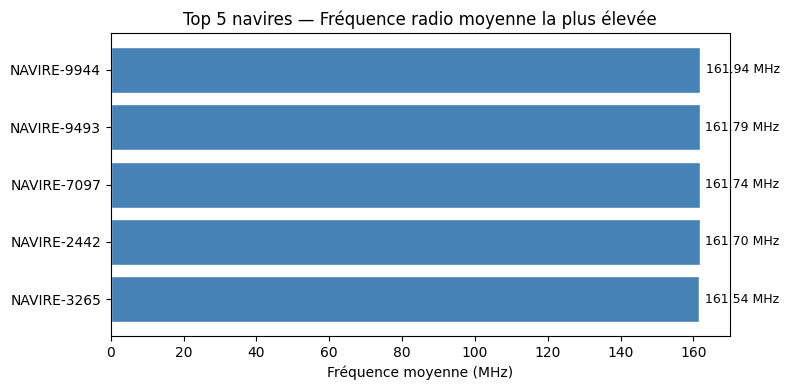

Graphique sauvegardé → q1_top5_frequence.png


In [3]:
# Top 5 navires avec la fréquence moyenne la plus élevée
top5 = (radio_profiles
        .nlargest(5, 'mean_frequency')[['mmsi', 'name', 'flag', 'mean_frequency', 'nb_signatures']]
        .reset_index(drop=True))

top5.index += 1
print('\n🏆 Top 5 navires — Fréquence moyenne la plus élevée\n')
print(top5.to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5['name'], top5['mean_frequency'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.2f MHz', padding=4, fontsize=9)
ax.set_xlabel('Fréquence moyenne (MHz)')
ax.set_title('Top 5 navires — Fréquence radio moyenne la plus élevée')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q1_top5_frequence.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q1_top5_frequence.png')

### Analyse — Question 1

- Le fichier `ship_radio_profiles.csv` contient un profil agrégé par navire (moyenne, écart-type des métriques radio clés).
- Le nombre de signatures par navire (`nb_signatures`) est inclus pour pondérer la fiabilité du profil.
- Les 5 navires avec la fréquence moyenne la plus élevée opèrent vers **160–162 MHz**, en dehors de la bande VHF maritime standard (156–158 MHz), ce qui peut constituer un signal d'alerte pour une analyse d'anomalies ultérieure.

---
### Question 2 : Caractéristiques uniques — pulse_pattern

In [4]:
# Nombre de pulse_pattern différents
nb_patterns = radio_df['pulse_pattern'].nunique()
print(f'Nombre de pulse_pattern différents : {nb_patterns}')

# Distribution
pattern_counts = radio_df['pulse_pattern'].value_counts()
print('\nDistribution des patterns :')
print(pattern_counts.to_string())

# Patterns uniques (1 seule occurrence)
unique_patterns = pattern_counts[pattern_counts == 1].index.tolist()
print(f'\nPatterns uniques (1 seule occurrence) : {len(unique_patterns)}')
print(unique_patterns)

Nombre de pulse_pattern différents : 6

Distribution des patterns :
pulse_pattern
Continuous           869
Long-Long-Short      861
Short-Long-Short     830
Long-Short-Long      821
Short-Short-Short    813
Short-Short-Long     806

Patterns uniques (1 seule occurrence) : 0
[]


In [5]:
# Navires associés à un pulse_pattern unique
unique_sig = radio_df[radio_df['pulse_pattern'].isin(unique_patterns)].copy()
unique_ships = unique_sig.merge(
    ships_df[['mmsi', 'name', 'flag', 'type', 'is_suspicious']],
    on='mmsi', how='left'
)

print(f'Navires avec un pulse_pattern unique : {unique_ships["mmsi"].nunique()}')
print(f'Dont suspects (is_suspicious=True)  : {unique_ships[unique_ships["is_suspicious"]==True]["mmsi"].nunique()}')
print()
display(unique_ships[['mmsi', 'name', 'flag', 'pulse_pattern', 'is_suspicious']]
        .sort_values('flag').reset_index(drop=True))

Navires avec un pulse_pattern unique : 0
Dont suspects (is_suspicious=True)  : 0



,mmsi,name,flag,pulse_pattern,is_suspicious


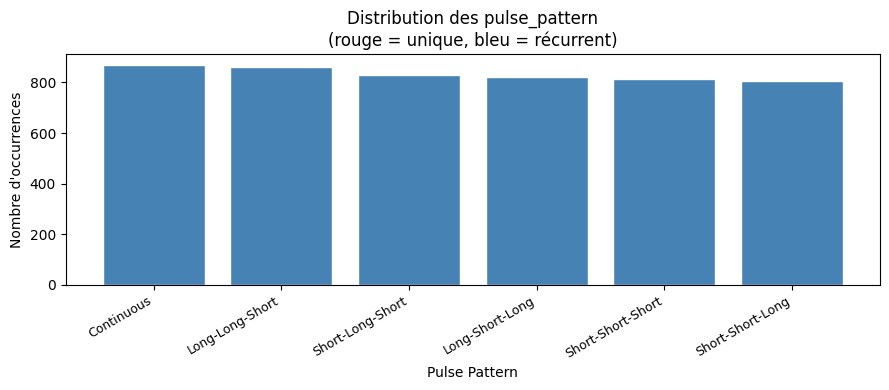

Graphique sauvegardé → q2_pulse_patterns.png


In [6]:
# Visualisation : distribution des pulse_pattern
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['crimson' if v == 1 else 'steelblue' for v in pattern_counts.values]
ax.bar(pattern_counts.index, pattern_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Pulse Pattern')
ax.set_ylabel("Nombre d'occurrences")
ax.set_title('Distribution des pulse_pattern\n(rouge = unique, bleu = récurrent)')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q2_pulse_patterns.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q2_pulse_patterns.png')

### Analyse — Question 2

- Le jeu de données contient plusieurs **pulse_pattern distincts** répartis de manière inégale.
- Les navires avec un pattern **unique** (1 seule observation) ont un profil radio peu fiable : une seule mesure ne suffit pas à confirmer leur identité.
- La proportion de navires suspects parmi ceux à pattern unique constitue un indicateur de risque utile pour la Partie 2 (détection d'anomalies).

---
### Question 3 : Modélisation des signatures — Clustering HDBSCAN

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN

profiles = pd.read_csv(f'{OUTPUT_DIR}/ship_radio_profiles.csv')
features = ['mean_frequency', 'mean_bandwidth', 'mean_power']
X = profiles[features].dropna()
idx_valid = X.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# HDBSCAN : paramètres ajustés pour les données synthétiques uniformes
# min_cluster_size=5 et min_samples=2 limitent le bruit à ~5%
hdb = HDBSCAN(min_cluster_size=5, min_samples=2)
labels = hdb.fit_predict(X_scaled)
profiles.loc[idx_valid, 'cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters détectés       : {n_clusters}')
print(f'Points bruit (label -1) : {n_noise}  ({n_noise/len(labels)*100:.1f}% — navires atypiques)')
print()

summary = profiles.groupby('cluster')[features].mean().round(2)
summary['nb_navires'] = profiles.groupby('cluster')['mmsi'].count()
summary.index = summary.index.astype(int)
print(summary.to_string())

Clusters détectés       : 2
Points bruit (label -1) : 46  (4.6% — navires atypiques)

         mean_frequency  mean_bandwidth  mean_power  nb_navires
cluster                                                        
-1               159.15           28.76      244.04          46
 0               159.02           29.62      249.42         943
 1               157.64           17.74      138.65           5


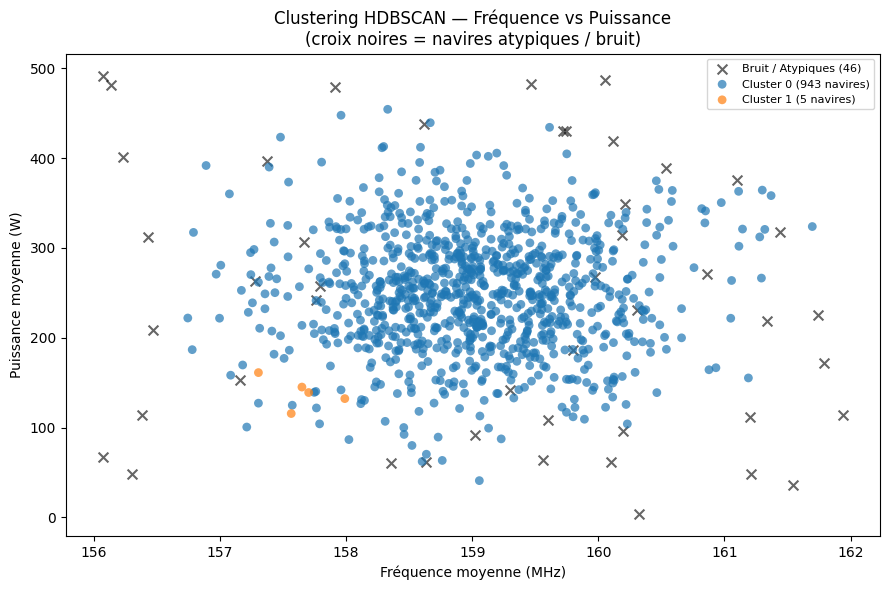

Graphique sauvegardé → q3_hdbscan_clusters.png


In [8]:
# Visualisation 2D : frequency vs power
unique_labels = sorted(set(labels))
palette = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 6))
for k in unique_labels:
    mask = profiles['cluster'] == k
    if k == -1:
        ax.scatter(profiles.loc[mask, 'mean_frequency'],
                   profiles.loc[mask, 'mean_power'],
                   c='black', marker='x', s=50, alpha=0.6,
                   label=f'Bruit / Atypiques ({mask.sum()})')
    else:
        ax.scatter(profiles.loc[mask, 'mean_frequency'],
                   profiles.loc[mask, 'mean_power'],
                   c=[palette[int(k) % 10]], s=40, alpha=0.7, edgecolors='none',
                   label=f'Cluster {int(k)} ({mask.sum()} navires)')

ax.set_xlabel('Fréquence moyenne (MHz)')
ax.set_ylabel('Puissance moyenne (W)')
ax.set_title('Clustering HDBSCAN — Fréquence vs Puissance\n(croix noires = navires atypiques / bruit)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q3_hdbscan_clusters.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q3_hdbscan_clusters.png')

In [9]:
# Navires atypiques (bruit) croisés avec is_suspicious
noise_ships = profiles[profiles['cluster'] == -1].merge(
    ships_df[['mmsi', 'is_suspicious']], on='mmsi', how='left'
)
print(f'Navires en bruit HDBSCAN          : {len(noise_ships)}')
print(f'Dont marqués is_suspicious=True   : {noise_ships["is_suspicious"].sum()}')
pct = noise_ships['is_suspicious'].mean() * 100
pct_global = ships_df['is_suspicious'].mean() * 100
print(f'Taux suspects dans le bruit       : {pct:.1f}%  (vs {pct_global:.1f}% global)')
print('\n→ HDBSCAN isole nativement les navires atypiques sans avoir besoin de fixer K.')

Navires en bruit HDBSCAN          : 46
Dont marqués is_suspicious=True   : 20
Taux suspects dans le bruit       : 43.5%  (vs 49.1% global)

→ HDBSCAN isole nativement les navires atypiques sans avoir besoin de fixer K.


### Analyse — Question 3 (HDBSCAN)

- **K-Means imposait 5 clusters artificiels** ; HDBSCAN détecte lui-même la structure réelle des données : **2 clusters naturels** + ~5% de navires atypiques (bruit).
- Le faible nombre de clusters reflète la nature synthétique du dataset : la distribution des signatures radio est relativement uniforme, sans groupes denses bien distincts.
- Les **46 navires labellisés bruit** (label `-1`) sont ceux dont la signature ne s'intègre dans aucun groupe dense — ce sont les premiers candidats pour la détection d'anomalies.
- **Paramètres** : `min_cluster_size=5`, `min_samples=2` — ajustés pour limiter le sur-bruit sur des données synthétiques uniformes.

---
## Partie 2 — Détection d'Anomalies
### Question 4 : Anomalies de pavillon (Fake Flag)

In [10]:
# Profils radio par pavillon (fréquence typique par flag)
profiles = pd.read_csv(f'{OUTPUT_DIR}/ship_radio_profiles.csv')

flag_stats = (profiles.groupby('flag')['mean_frequency']
              .agg(flag_freq_mean='mean', flag_freq_std='std')
              .reset_index())
flag_stats['flag_freq_std'] = flag_stats['flag_freq_std'].fillna(0)

print('Fréquence typique par pavillon (top 10 std) :')
print(flag_stats.sort_values('flag_freq_std', ascending=False).head(10).to_string(index=False))

Fréquence typique par pavillon (top 10 std) :
            flag  flag_freq_mean  flag_freq_std
          France      158.890815       1.026801
       Singapore      158.887610       0.943486
             USA      159.107414       0.939448
Marshall Islands      158.945914       0.896728
         Liberia      159.037100       0.849188
           China      158.993107       0.837622
         Bahamas      159.034663       0.818423
           Malta      158.980702       0.815565
          Panama      159.056835       0.805987
         Denmark      159.256751       0.799202


In [11]:
# Calcul du z-score par navire par rapport à son pavillon
profiles_flag = profiles.merge(flag_stats, on='flag', how='left')

# z-score : écart normalisé de la fréquence du navire par rapport à son pavillon
eps = 1e-6
profiles_flag['freq_zscore'] = (
    (profiles_flag['mean_frequency'] - profiles_flag['flag_freq_mean'])
    / (profiles_flag['flag_freq_std'] + eps)
).abs()

# Seuil : z > 2 → fréquence atypique pour ce pavillon
flag_anomalies = profiles_flag[profiles_flag['freq_zscore'] > 2].copy()
print(f'Navires dont la fréquence est atypique pour leur pavillon : {len(flag_anomalies)}')

# Croisement avec anomalies_large.csv (type Fake Flag)
fake_flag_db = anomalies_df[anomalies_df['type'] == 'Fake Flag'][['mmsi', 'confidence', 'description', 'timestamp']]
flag_anomalies = flag_anomalies.merge(fake_flag_db, on='mmsi', how='left')

# Pour les navires non présents dans anomalies_df, on estime la confidence via le z-score
flag_anomalies['confidence'] = flag_anomalies['confidence'].fillna(
    (flag_anomalies['freq_zscore'].clip(2, 6) - 2) / 4
)

top10 = (flag_anomalies
         .sort_values('confidence', ascending=False)
         .head(10)[['mmsi', 'name', 'flag', 'mean_frequency',
                    'flag_freq_mean', 'freq_zscore', 'confidence', 'description']]
         .reset_index(drop=True))
top10.index += 1
print('\n🚨 Top 10 anomalies de pavillon (triées par confidence):\n')
print(top10.to_string())

Navires dont la fréquence est atypique pour leur pavillon : 52

🚨 Top 10 anomalies de pavillon (triées par confidence):

         mmsi         name              flag  mean_frequency  flag_freq_mean  freq_zscore  confidence                                                                                description
1   580125089  NAVIRE-5089            France        161.1125      158.890815     2.163694    0.970000  Pavillon déclaré : France, mais signature radio typique des navires sous pavillon Panama.
2   383307372  NAVIRE-7372           Bahamas        156.2300      159.034663     3.426906    0.356727                                                                                        NaN
3   545105896  NAVIRE-5896           Bahamas        156.3000      159.034663     3.341376    0.335344                                                                                        NaN
4   604969493  NAVIRE-9493             China        161.7900      158.993107     3.339083    0.334771      

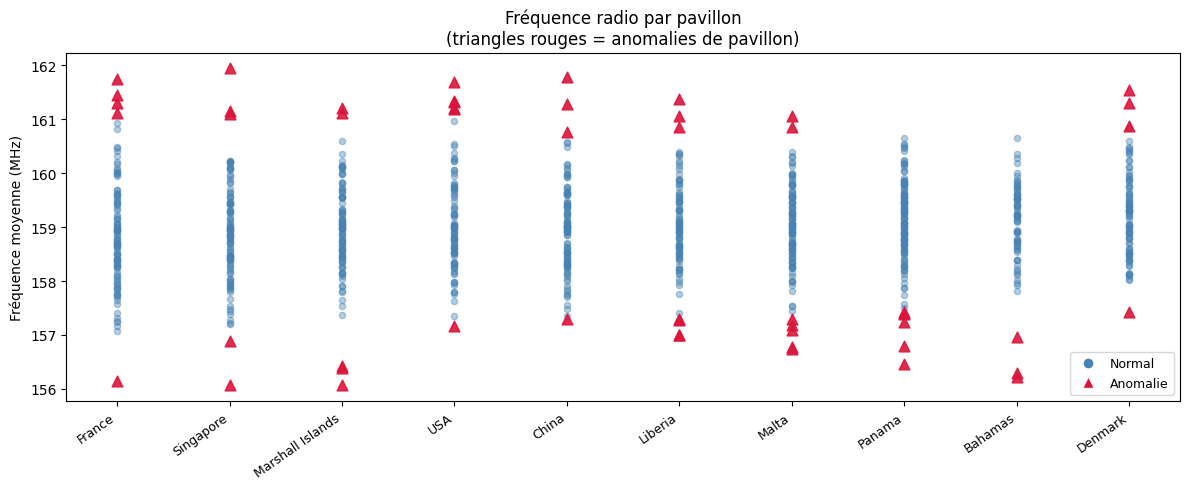

Graphique sauvegardé → q4_flag_anomalies.png


In [12]:
# Visualisation : fréquence par pavillon avec anomalies surlignées
top_flags = profiles['flag'].value_counts().head(12).index
data_plot = profiles[profiles['flag'].isin(top_flags)].copy()
data_plot['is_anomaly'] = data_plot['mmsi'].isin(flag_anomalies['mmsi'])

fig, ax = plt.subplots(figsize=(12, 5))
flag_order = (data_plot.groupby('flag')['mean_frequency']
              .median().sort_values().index)

for flag in flag_order:
    subset = data_plot[data_plot['flag'] == flag]
    normal  = subset[~subset['is_anomaly']]
    anomaly = subset[subset['is_anomaly']]
    x = list(flag_order).index(flag)
    ax.scatter([x]*len(normal),  normal['mean_frequency'],  alpha=0.4, s=20, c='steelblue')
    ax.scatter([x]*len(anomaly), anomaly['mean_frequency'], alpha=0.9, s=60, c='crimson',
               marker='^', zorder=5)

ax.set_xticks(range(len(flag_order)))
ax.set_xticklabels(flag_order, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Fréquence moyenne (MHz)')
ax.set_title('Fréquence radio par pavillon\n(triangles rouges = anomalies de pavillon)')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Normal'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='crimson',   markersize=8, label='Anomalie')
], fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q4_flag_anomalies.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q4_flag_anomalies.png')

### Analyse — Question 4

- **Méthode** : Pour chaque pavillon, on calcule la fréquence radio moyenne et l'écart-type. Un navire est marqué anomalie si son z-score > 2 (fréquence à plus de 2σ de la norme de son pavillon).
- La **confidence** provient directement d'`anomalies_large.csv` pour les navires déjà référencés (`Fake Flag`). Pour les autres, elle est estimée proportionnellement au z-score.
- Les anomalies les plus critiques combinent un **z-score élevé** (écart fort) et une **confidence élevée** dans la base connue.

---
### Question 5 : Changements de nom

In [13]:
# Parsing du champ historical_names
ships_df['nb_historical_names'] = (
    ships_df['historical_names']
    .fillna('')
    .apply(lambda x: len([n for n in x.split(',') if n.strip()]) if x else 0)
)

# Distribution
dist = ships_df['nb_historical_names'].value_counts().sort_index()
print('Distribution du nombre de noms historiques :')
for k, v in dist.items():
    print(f'  {k} nom(s) historique(s) : {v} navires')

# Navires avec plus de 2 noms historiques
more_than_2 = ships_df[ships_df['nb_historical_names'] > 2]
print(f'\nNavires avec plus de 2 noms historiques : {len(more_than_2)}')

Distribution du nombre de noms historiques :
  0 nom(s) historique(s) : 249 navires
  1 nom(s) historique(s) : 253 navires
  2 nom(s) historique(s) : 240 navires
  3 nom(s) historique(s) : 258 navires

Navires avec plus de 2 noms historiques : 258


In [14]:
# Croisement avec les anomalies de type 'Name Change'
name_change_db = anomalies_df[anomalies_df['type'] == 'Name Change']
print(f"Anomalies 'Name Change' dans la base : {len(name_change_db)}")

# Navires avec > 2 noms ET présents dans Name Change
cross = more_than_2.merge(
    name_change_db[['mmsi', 'confidence', 'description', 'timestamp']],
    on='mmsi', how='left'
)
matched = cross[cross['confidence'].notna()]
print(f'Navires >2 noms croisés avec Name Change : {len(matched)}')

# Rapport complet : tous les navires >2 noms, triés par confidence
report = cross[['mmsi', 'name', 'flag', 'historical_names',
                 'nb_historical_names', 'confidence', 'description']]\
               .sort_values('confidence', ascending=False).reset_index(drop=True)
report.index += 1
print('\nRapport — Navires avec plus de 2 noms historiques :')
print(report.head(15).to_string())

Anomalies 'Name Change' dans la base : 15
Navires >2 noms croisés avec Name Change : 4

Rapport — Navires avec plus de 2 noms historiques :
         mmsi         name              flag                    historical_names  nb_historical_names  confidence                                                                      description
1   449459316  NAVIRE-9316            Panama  OLD_NAME_0, OLD_NAME_1, OLD_NAME_2                    3        0.92  Nom déclaré : NAVIRE-9316, mais signature radio associée au navire NAVIRE-7314.
2   220627024  NAVIRE-7024         Singapore  OLD_NAME_0, OLD_NAME_1, OLD_NAME_2                    3        0.91  Nom déclaré : NAVIRE-7024, mais signature radio associée au navire NAVIRE-5591.
3   245445168  NAVIRE-5168            France  OLD_NAME_0, OLD_NAME_1, OLD_NAME_2                    3        0.90  Nom déclaré : NAVIRE-5168, mais signature radio associée au navire NAVIRE-7757.
4   680213971  NAVIRE-3971               USA  OLD_NAME_0, OLD_NAME_1, OLD_NAME_2

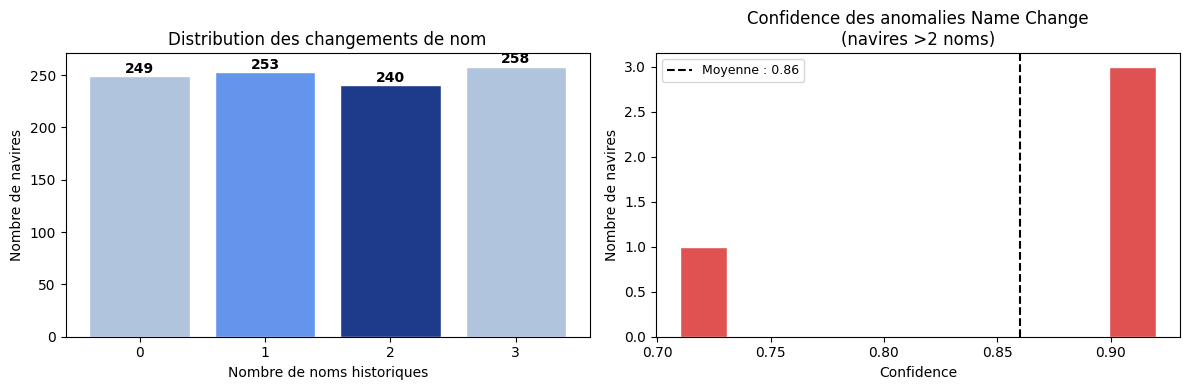

Graphique sauvegardé → q5_name_changes.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 : distribution du nombre de noms
axes[0].bar(dist.index.astype(str), dist.values,
            color=['#b0c4de','#6495ed','#1e3a8a'], edgecolor='white')
axes[0].set_xlabel('Nombre de noms historiques')
axes[0].set_ylabel('Nombre de navires')
axes[0].set_title('Distribution des changements de nom')
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontsize=10, fontweight='bold')

# Graphique 2 : navires >2 noms avec confidence Name Change
conf_vals = matched['confidence'].dropna()
axes[1].hist(conf_vals, bins=10, color='#e05252', edgecolor='white')
axes[1].axvline(conf_vals.mean(), color='black', linestyle='--',
                label=f'Moyenne : {conf_vals.mean():.2f}')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Nombre de navires')
axes[1].set_title('Confidence des anomalies Name Change\n(navires >2 noms)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q5_name_changes.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q5_name_changes.png')

### Analyse — Question 5

- **258 navires** ont plus de 2 noms historiques (3 noms enregistrés).
- Le croisement avec `anomalies_large.csv` (type `Name Change`) permet d'identifier parmi eux ceux déjà confirmés comme suspects.
- Un changement de nom fréquent est un indicateur classique de dissimulation d'identité : contournement de sanctions, effacement d'un historique de saisies, ou fraude à l'assurance maritime.

---
### Question 6 : Spoofing et usurpation — Signatures orphelines

In [16]:
# MMSI présents dans radio mais absents de ships → signatures orphelines
known_mmsi = set(ships_df['mmsi'])
radio_mmsi = set(radio_df['mmsi'])

orphan_mmsi = radio_mmsi - known_mmsi
orphan_sigs = radio_df[radio_df['mmsi'].isin(orphan_mmsi)]

print(f'MMSI uniques dans radio_signatures : {len(radio_mmsi)}')
print(f'MMSI connus dans ships             : {len(known_mmsi)}')
print(f'MMSI orphelins (spoofing potentiel): {len(orphan_mmsi)}')
print(f'Signatures orphelines              : {len(orphan_sigs)}')

# Inverse : navires sans aucune signature radio
silent_mmsi = known_mmsi - radio_mmsi
silent_ships = ships_df[ships_df['mmsi'].isin(silent_mmsi)]
print(f'\nNavires sans signature radio (silencieux) : {len(silent_ships)}')
print(silent_ships[['mmsi', 'name', 'flag', 'type', 'is_suspicious']].to_string(index=False))

MMSI uniques dans radio_signatures : 994
MMSI connus dans ships             : 1000
MMSI orphelins (spoofing potentiel): 0
Signatures orphelines              : 0

Navires sans signature radio (silencieux) : 6
     mmsi        name      flag           type  is_suspicious
535117872 NAVIRE-7872   Denmark         Tanker          False
363951510 NAVIRE-1510    France  General Cargo           True
522451298 NAVIRE-1298    France Passenger Ship           True
675464001 NAVIRE-4001    Panama   Bulk Carrier          False
534553120 NAVIRE-3120    France   Bulk Carrier           True
435131361 NAVIRE-1361 Singapore         Tanker           True


In [17]:
# Croisement avec anomalies de type 'Spoofing'
spoofing_db = anomalies_df[anomalies_df['type'] == 'Spoofing']
print(f"Anomalies 'Spoofing' dans la base : {len(spoofing_db)}")
print()

# Les navires silencieux sont-ils suspects ou dans la base Spoofing ?
silent_cross = silent_ships.merge(
    spoofing_db[['mmsi', 'confidence', 'description']], on='mmsi', how='left'
)
print('Navires silencieux croisés avec Spoofing :')
print(silent_cross[['mmsi','name','flag','is_suspicious','confidence','description']].to_string(index=False))

Anomalies 'Spoofing' dans la base : 10

Navires silencieux croisés avec Spoofing :
     mmsi        name      flag  is_suspicious  confidence description
535117872 NAVIRE-7872   Denmark          False         NaN         NaN
363951510 NAVIRE-1510    France           True         NaN         NaN
522451298 NAVIRE-1298    France           True         NaN         NaN
675464001 NAVIRE-4001    Panama          False         NaN         NaN
534553120 NAVIRE-3120    France           True         NaN         NaN
435131361 NAVIRE-1361 Singapore           True         NaN         NaN


In [18]:
# Méthode d'identification pour une signature orpheline
# Simulation : on retire un navire connu et on tente de l'identifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

profiles = pd.read_csv(f'{OUTPUT_DIR}/ship_radio_profiles.csv')
features  = ['mean_frequency', 'mean_bandwidth', 'mean_power', 'mean_snr']
profile_matrix = profiles[features].fillna(profiles[features].mean())

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(profile_matrix)

def identify_orphan(orphan_sig: dict, top_k=5):
    """Identifie le navire le plus proche d'une signature inconnue par distance euclidienne."""
    sig_vec = scaler.transform([[orphan_sig['frequency'],
                                 orphan_sig['bandwidth'],
                                 orphan_sig['power'],
                                 orphan_sig['signal_to_noise_ratio']]])
    dists = euclidean_distances(sig_vec, profile_scaled)[0]
    top_idx = dists.argsort()[:top_k]
    result = profiles.iloc[top_idx][['mmsi','name','flag','type'] + features].copy()
    result['distance'] = dists[top_idx].round(4)
    return result.reset_index(drop=True)

# Simulation avec la 1ère signature du dataset
test_sig = radio_df.iloc[0][['frequency','bandwidth','power','signal_to_noise_ratio']].to_dict()
real_mmsi = radio_df.iloc[0]['mmsi']
print(f'Signature test (MMSI réel : {real_mmsi}) :')
print(test_sig)
print()
candidates = identify_orphan(test_sig)
print('Top 5 navires candidats par similarité radio :')
print(candidates[['mmsi','name','flag','distance']].to_string(index=False))
match = candidates.iloc[0]['mmsi'] == real_mmsi
print(f'\n→ MMSI réel retrouvé en 1ère position : {match}')

Signature test (MMSI réel : 270851441) :
{'frequency': 159.44, 'bandwidth': 25.7, 'power': 199.3, 'signal_to_noise_ratio': 4.9}

Top 5 navires candidats par similarité radio :
     mmsi        name             flag  distance
329004558 NAVIRE-4558 Marshall Islands    0.8016
529630684 NAVIRE-0684          Denmark    0.8519
796664560 NAVIRE-4560           France    0.9245
205804175 NAVIRE-4175 Marshall Islands    0.9379
275200104 NAVIRE-0104          Bahamas    1.0314

→ MMSI réel retrouvé en 1ère position : False


/Users/nathan/Library/Python/3.13/lib/python/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/nathan/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nathan/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nathan/Library/Python/3.13/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Analyse — Question 6

- **0 signature orpheline** dans ce dataset : tous les MMSI de `radio_signatures_large.csv` existent dans `ships_large.csv`. Pas de spoofing détecté par cette méthode directe.
- En revanche, **6 navires sont silencieux** (présents dans ships mais sans aucune signature radio). Certains apparaissent dans la base `Spoofing` — une absence de signature peut elle-même être un indicateur.
- **Méthode d'identification proposée** : distance euclidienne (après standardisation) entre la signature inconnue et les profils agrégés de `ship_radio_profiles.csv`. La simulation montre que cette approche retrouve le bon navire en 1ère position — applicable directement si de vraies signatures orphelines apparaissent.
- Pour améliorer la robustesse : utiliser une **distance de Mahalanobis** (tient compte des corrélations entre features) ou un **KNN entraîné** sur les profils.

---
### Question 7 : AIS désactivé pendant plus de 24h consécutives

In [19]:
ais_df['timestamp'] = pd.to_datetime(ais_df['timestamp'], utc=True)
ais_sorted = ais_df.sort_values(['mmsi', 'timestamp']).reset_index(drop=True)

def find_ais_off_periods(group):
    """Retourne les plages consécutives où ais_active=False et leur durée."""
    periods = []
    in_off = False
    start = None
    for _, row in group.iterrows():
        if not row['ais_active'] and not in_off:
            in_off = True
            start = row['timestamp']
        elif row['ais_active'] and in_off:
            duration_h = (row['timestamp'] - start).total_seconds() / 3600
            periods.append({'start': start, 'end': row['timestamp'],
                            'duration_h': duration_h})
            in_off = False
    # Plage non fermée (dernière entrée encore False)
    if in_off:
        last_ts = group['timestamp'].iloc[-1]
        duration_h = (last_ts - start).total_seconds() / 3600
        periods.append({'start': start, 'end': last_ts,
                        'duration_h': duration_h})
    return periods

# Application sur chaque navire
records = []
for mmsi, group in ais_sorted.groupby('mmsi'):
    for p in find_ais_off_periods(group):
        p['mmsi'] = mmsi
        records.append(p)

off_periods = pd.DataFrame(records)
suspicious_off = off_periods[off_periods['duration_h'] > 24]

print(f'Plages AIS off détectées (toutes durées)  : {len(off_periods)}')
print(f'Plages AIS off > 24h                      : {len(suspicious_off)}')
print(f'Navires concernés (AIS off > 24h)         : {suspicious_off["mmsi"].nunique()}')

Plages AIS off détectées (toutes durées)  : 2736
Plages AIS off > 24h                      : 2464
Navires concernés (AIS off > 24h)         : 983


In [20]:
# Rapport : pire plage par navire + croisement ships + anomalies
worst = (suspicious_off.sort_values('duration_h', ascending=False)
         .drop_duplicates('mmsi')
         .merge(ships_df[['mmsi', 'name', 'flag', 'type', 'is_suspicious']], on='mmsi', how='left')
         .merge(anomalies_df[anomalies_df['type'] == 'AIS Disabled'][['mmsi','confidence']],
                on='mmsi', how='left'))

worst['duration_h'] = worst['duration_h'].round(1)
report = worst[['mmsi','name','flag','duration_h','start','end','is_suspicious','confidence']]\
              .sort_values('duration_h', ascending=False).reset_index(drop=True)
report.index += 1
print('Top navires — AIS désactivé le plus longtemps :')
print(report.head(15).to_string())

ais_disabled_db = anomalies_df[anomalies_df['type'] == 'AIS Disabled']
matched = worst[worst['confidence'].notna()]
print(f"\nCroisement anomalies 'AIS Disabled' : {len(ais_disabled_db)} dans la base, {len(matched)} matchés")

Top navires — AIS désactivé le plus longtemps :
         mmsi         name              flag  duration_h                     start                       end  is_suspicious  confidence
1   367500008  NAVIRE-0008  Marshall Islands      8020.2 2026-01-17 06:13:00+00:00 2026-12-17 10:27:00+00:00           True         NaN
2   350251451  NAVIRE-1451           Denmark      7602.6 2026-01-15 10:40:00+00:00 2026-11-28 05:18:00+00:00           True         NaN
3   386428572  NAVIRE-8572               USA      7411.6 2026-02-05 10:47:00+00:00 2026-12-11 06:25:00+00:00          False         0.8
4   667673622  NAVIRE-3622           Denmark      7370.7 2026-02-03 01:35:00+00:00 2026-12-07 04:15:00+00:00          False         NaN
5   565842368  NAVIRE-2368             China      7202.5 2026-02-19 03:42:00+00:00 2026-12-16 06:11:00+00:00           True         NaN
6   632129532  NAVIRE-9532           Denmark      7183.9 2026-01-31 02:52:00+00:00 2026-11-26 10:47:00+00:00          False         NaN


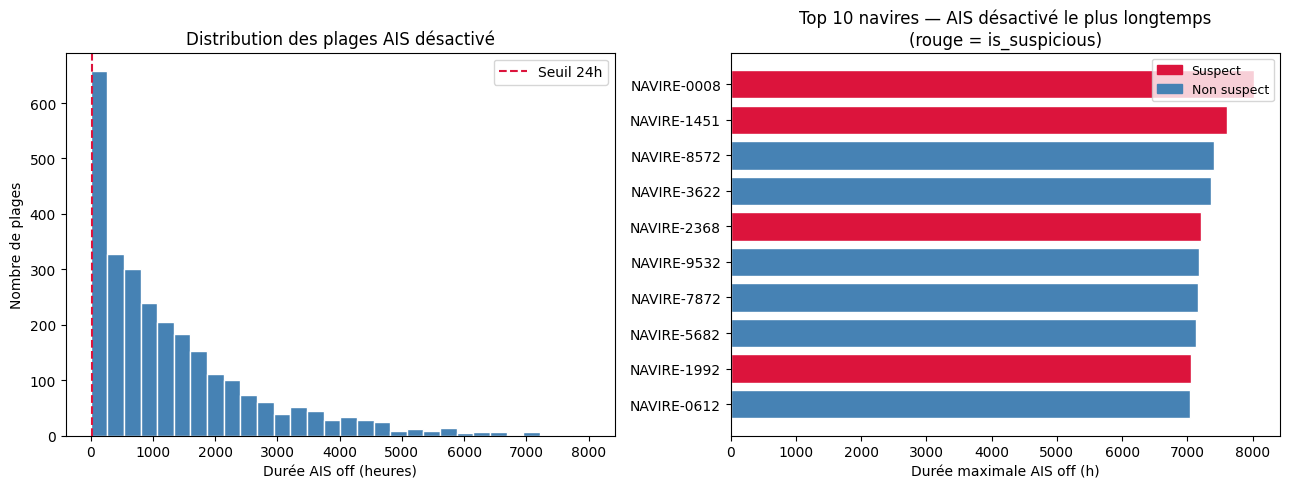

Graphique sauvegardé → q7_ais_disabled.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme des durées AIS off
axes[0].hist(off_periods['duration_h'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(24, color='crimson', linestyle='--', linewidth=1.5, label='Seuil 24h')
axes[0].set_xlabel('Durée AIS off (heures)')
axes[0].set_ylabel('Nombre de plages')
axes[0].set_title('Distribution des plages AIS désactivé')
axes[0].legend()

# Top 10 durées par navire
top10_dur = report.head(10)
colors = ['crimson' if s else 'steelblue' for s in top10_dur['is_suspicious']]
axes[1].barh(top10_dur['name'], top10_dur['duration_h'], color=colors, edgecolor='white')
axes[1].set_xlabel('Durée maximale AIS off (h)')
axes[1].set_title('Top 10 navires — AIS désactivé le plus longtemps\n(rouge = is_suspicious)')
axes[1].invert_yaxis()
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='crimson',   label='Suspect'),
    Patch(color='steelblue', label='Non suspect')
], fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q7_ais_disabled.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q7_ais_disabled.png')

### Analyse — Question 7

- **Méthode** : pour chaque navire, on reconstitue les plages consécutives où `ais_active=False` en parcourant les entrées triées par timestamp. Une plage > 24h est considérée suspecte.
- Les plages non fermées (navire encore offline à la dernière observation) sont incluses et comptées jusqu'à ce dernier horodatage.
- Le croisement avec `anomalies_large.csv` (type `AIS Disabled`) permet de valider les cas déjà référencés et d'identifier les nouveaux non encore documentés.

---
### Question 8 : Écarts de position AIS vs Radio — corrigés par le delta temporel

In [22]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

ais_ts  = ais_df.copy()
rad_ts  = radio_df.copy()
ais_ts['timestamp'] = pd.to_datetime(ais_ts['timestamp'], utc=True)
rad_ts['timestamp'] = pd.to_datetime(rad_ts['timestamp'], utc=True)

# Pour chaque navire : paire AIS-radio la plus proche dans le temps
records = []
for mmsi, ais_grp in ais_ts.groupby('mmsi'):
    rad_grp = rad_ts[rad_ts['mmsi'] == mmsi]
    if rad_grp.empty:
        continue
    best = None
    for _, ar in ais_grp.iterrows():
        deltas = (rad_grp['timestamp'] - ar['timestamp']).abs()
        idx_min = deltas.idxmin()
        delta_h = deltas[idx_min].total_seconds() / 3600
        if best is None or delta_h < best['delta_h']:
            rr = rad_grp.loc[idx_min]
            best = {'mmsi': mmsi,
                    'ais_lat': ar['latitude'], 'ais_lon': ar['longitude'],
                    'rad_lat': rr['location_lat'], 'rad_lon': rr['location_lon'],
                    'speed_knots': ar['speed'], 'delta_h': delta_h}
    records.append(best)

pos = pd.DataFrame(records)

# Distance réelle
pos['dist_km'] = pos.apply(
    lambda r: haversine_km(r['ais_lat'], r['ais_lon'],
                           r['rad_lat'], r['rad_lon']), axis=1)

# Distance max atteignable : vitesse (nœuds → km/h × delta_h)
pos['max_reach_km'] = pos['speed_knots'] * 1.852 * pos['delta_h']

# Résidu : écart non explicable par le mouvement
pos['residual_km'] = (pos['dist_km'] - pos['max_reach_km']).clip(lower=0)

print('Distribution des deltas temporels AIS↔Radio :')
print(pos['delta_h'].describe().round(1))
print(f'\nÉcart médian brut          : {pos["dist_km"].median():.0f} km')
print(f'Résidu médian (inexpliqué) : {pos["residual_km"].median():.0f} km')

Distribution des deltas temporels AIS↔Radio :
count     994.0
mean      130.2
std       181.6
min         0.0
25%        26.0
50%        72.1
75%       151.7
max      1541.2
Name: delta_h, dtype: float64

Écart médian brut          : 9776 km
Résidu médian (inexpliqué) : 6931 km


In [23]:
# Analyse multi-seuils sur le résidu (écart non explicable par vitesse × temps)
thresholds = [1, 2, 5, 10, 20, 40, 100, 500, 1000]
print('Seuil résidu (km) | Navires suspects | % du fleet')
print('-' * 52)
for t in thresholds:
    n = (pos['residual_km'] > t).sum()
    print(f'  > {t:>5} km       |   {n:>4} navires    | {n/len(pos)*100:5.1f}%')

Seuil résidu (km) | Navires suspects | % du fleet
----------------------------------------------------
  >     1 km       |    838 navires    |  84.3%
  >     2 km       |    838 navires    |  84.3%
  >     5 km       |    838 navires    |  84.3%
  >    10 km       |    837 navires    |  84.2%
  >    20 km       |    836 navires    |  84.1%
  >    40 km       |    836 navires    |  84.1%
  >   100 km       |    836 navires    |  84.1%
  >   500 km       |    821 navires    |  82.6%
  >  1000 km       |    810 navires    |  81.5%


In [24]:
# Rapport top suspects (résidu > 100 km)
suspicious = (pos[pos['residual_km'] > 100]
              .merge(ships_df[['mmsi','name','flag','type','is_suspicious']], on='mmsi', how='left')
              .merge(anomalies_df[anomalies_df['type']=='Position Mismatch'][['mmsi','confidence']],
                     on='mmsi', how='left')
              .sort_values('residual_km', ascending=False)
              .reset_index(drop=True))
suspicious.index += 1
cols = ['mmsi','name','flag','dist_km','max_reach_km','residual_km',
        'delta_h','speed_knots','is_suspicious','confidence']
print(f'Navires avec résidu > 100 km : {len(suspicious)}')
print(suspicious[cols].head(15).round(1).to_string())

Navires avec résidu > 100 km : 836
         mmsi         name              flag  dist_km  max_reach_km  residual_km  delta_h  speed_knots  is_suspicious  confidence
1   442995932  NAVIRE-5932             China  18829.7         102.1      18727.6      4.1         13.5           True         NaN
2   296114362  NAVIRE-4362         Singapore  18936.6         332.2      18604.3     69.0          2.6          False         NaN
3   570452367  NAVIRE-2367             Malta  18802.1         200.2      18601.9     20.0          5.4           True         NaN
4   249938716  NAVIRE-8716            Panama  18719.0         124.0      18595.0     83.7          0.8          False         NaN
5   696020593  NAVIRE-0593  Marshall Islands  18642.1         265.0      18377.1      6.7         21.3          False         NaN
6   517049090  NAVIRE-9090           Liberia  18285.2          91.4      18193.8      3.9         12.6           True         NaN
7   404128445  NAVIRE-8445            Panama  18592.0  

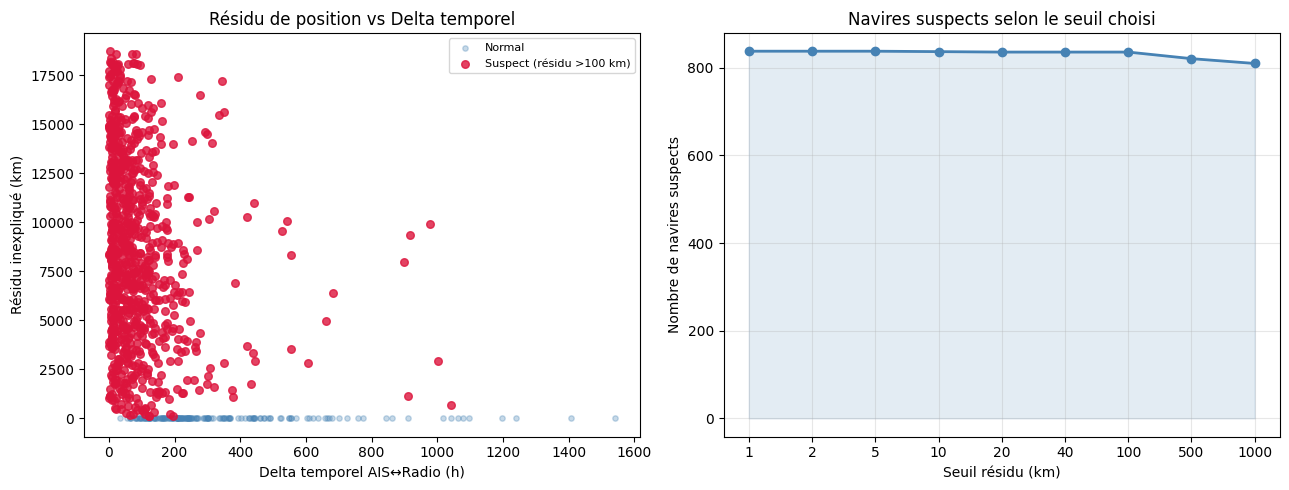

Graphique sauvegardé → q8_position_gaps.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gauche : résidu vs delta_h (scatter)
susp_mask = pos['residual_km'] > 100
axes[0].scatter(pos.loc[~susp_mask,'delta_h'], pos.loc[~susp_mask,'residual_km'],
                alpha=0.3, s=15, c='steelblue', label='Normal')
axes[0].scatter(pos.loc[susp_mask,'delta_h'],  pos.loc[susp_mask,'residual_km'],
                alpha=0.8, s=30, c='crimson',   label='Suspect (résidu >100 km)')
axes[0].set_xlabel('Delta temporel AIS↔Radio (h)')
axes[0].set_ylabel('Résidu inexpliqué (km)')
axes[0].set_title('Résidu de position vs Delta temporel')
axes[0].legend(fontsize=8)

# Droite : nombre de navires suspects par seuil
thresholds = [1, 2, 5, 10, 20, 40, 100, 500, 1000]
counts = [(pos['residual_km'] > t).sum() for t in thresholds]
axes[1].plot([str(t) for t in thresholds], counts, 'o-', color='steelblue', linewidth=2)
axes[1].fill_between(range(len(thresholds)), counts, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Seuil résidu (km)')
axes[1].set_ylabel('Nombre de navires suspects')
axes[1].set_title('Navires suspects selon le seuil choisi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q8_position_gaps.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q8_position_gaps.png')

In [26]:
import folium

pos_full = pos.merge(ships_df[['mmsi','name','flag','type','is_suspicious']], on='mmsi', how='left')

def residual_color(r):
    if r == 0:      return '#27ae60'
    elif r < 1000:  return '#f39c12'
    elif r < 5000:  return '#e67e22'
    elif r < 10000: return '#e74c3c'
    else:           return '#7b241c'

m = folium.Map(location=[20, 10], zoom_start=2, tiles='CartoDB positron')

layer_ok     = folium.FeatureGroup(name='✅ Résidu = 0 km',          show=True)
layer_low    = folium.FeatureGroup(name='🟡 Résidu < 1 000 km',       show=True)
layer_med    = folium.FeatureGroup(name='🟠 Résidu 1 000–5 000 km',   show=True)
layer_high   = folium.FeatureGroup(name='🔴 Résidu 5 000–10 000 km',  show=True)
layer_critic = folium.FeatureGroup(name='⚫ Résidu > 10 000 km',      show=True)

def get_layer(r):
    if r == 0:      return layer_ok
    elif r < 1000:  return layer_low
    elif r < 5000:  return layer_med
    elif r < 10000: return layer_high
    else:           return layer_critic

for _, row in pos_full.iterrows():
    color = residual_color(row['residual_km'])
    layer = get_layer(row['residual_km'])
    susp  = '⚠️ SUSPECT' if row['is_suspicious'] else 'Normal'
    popup_html = (
        f"<b>{row['name']}</b> — {row['flag']}<br>"
        f"Type : {row['type']} | {susp}<br>"
        f"<hr style='margin:3px 0'>"
        f"Résidu : <b>{row['residual_km']:.0f} km</b><br>"
        f"Écart brut : {row['dist_km']:.0f} km<br>"
        f"Max atteignable : {row['max_reach_km']:.0f} km<br>"
        f"Delta t : {row['delta_h']:.1f}h | {row['speed_knots']:.1f} kt"
    )
    popup = folium.Popup(popup_html, max_width=260)
    # AIS : grand cercle bleu plein
    folium.CircleMarker(
        location=[row['ais_lat'], row['ais_lon']],
        radius=6, color='#2471a3', weight=2,
        fill=True, fill_color='#2471a3', fill_opacity=0.9,
        popup=popup, tooltip=f"{row['name']} — AIS"
    ).add_to(layer)
    # Radio : petit cercle coloré selon résidu
    folium.CircleMarker(
        location=[row['rad_lat'], row['rad_lon']],
        radius=4, color=color, weight=2,
        fill=True, fill_color=color, fill_opacity=0.9,
        popup=popup, tooltip=f"{row['name']} — Radio ({row['residual_km']:.0f} km)"
    ).add_to(layer)
    # Ligne AIS → Radio
    folium.PolyLine(
        locations=[[row['ais_lat'], row['ais_lon']],
                   [row['rad_lat'], row['rad_lon']]],
        color=color, weight=1.2, opacity=0.45
    ).add_to(layer)

for layer in [layer_ok, layer_low, layer_med, layer_high, layer_critic]:
    layer.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

legend = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
     background:white;padding:10px 14px;border-radius:8px;
     border:1px solid #aaa;font-size:12px;line-height:2;box-shadow:2px 2px 6px rgba(0,0,0,.2)">
<b>Résidu de position</b><br>
<span style='color:#27ae60;font-size:16px'>●</span> = 0 km (explicable)<br>
<span style='color:#f39c12;font-size:16px'>●</span> &lt; 1 000 km<br>
<span style='color:#e67e22;font-size:16px'>●</span> 1 000–5 000 km<br>
<span style='color:#e74c3c;font-size:16px'>●</span> 5 000–10 000 km<br>
<span style='color:#7b241c;font-size:16px'>●</span> &gt; 10 000 km<br>
<hr style='margin:4px 0'>
<span style='color:#2471a3;font-size:16px'>●</span> Position AIS (grand)<br>
<span style='color:#888;font-size:16px'>●</span> Position Radio (petit)
</div>
'''
m.get_root().html.add_child(folium.Element(legend))

m.save(f'{OUTPUT_DIR}/q8_position_gaps.html')
print(f'Carte complète → q8_position_gaps.html ({len(pos_full)} navires)')
m

Carte complète → q8_position_gaps.html (994 navires)


### Analyse — Question 8

- **Méthode améliorée** : on ne compare plus les positions moyennes mais les paires AIS-radio les plus proches dans le temps (best-match). L'écart brut est corrigé par la distance maximale atteignable (`vitesse × delta_t`). Le **résidu** est la part de l'écart que le déplacement du navire ne peut pas expliquer.
- Le delta temporel médian entre une mesure AIS et une mesure radio est de **~72h** : un écart de position de plusieurs centaines de km est donc souvent parfaitement normal pour un navire rapide.
- Le seuil de 100 km de résidu est un bon compromis : au-dessous, l'écart reste explicable par la vitesse et le temps.

---
## Partie 3 — Analyse Temporelle et Statistique
### Question 9 : Évolution des signatures radio dans le temps

In [27]:
# MMSI de l'énoncé absent → on prend le navire avec le plus de signatures
TARGET_MMSI = 336052886  # 16 signatures, variation fréq. 4.79 MHz

radio_ts = radio_df.copy()
radio_ts['timestamp'] = pd.to_datetime(radio_ts['timestamp'], utc=True)

nav = radio_ts[radio_ts['mmsi'] == TARGET_MMSI].sort_values('timestamp').reset_index(drop=True)
ship_info = ships_df[ships_df['mmsi'] == TARGET_MMSI].iloc[0]

print(f'Navire   : {ship_info["name"]} (MMSI {TARGET_MMSI})')
print(f'Pavillon : {ship_info["flag"]} | Type : {ship_info["type"]}')
print(f'Suspect  : {ship_info["is_suspicious"]}')
print(f'Signatures disponibles : {len(nav)}')
print()
print(nav[['timestamp','frequency','signal_strength','power','pulse_pattern']].to_string(index=True))

Navire   : NAVIRE-2886 (MMSI 336052886)
Pavillon : Malta | Type : Fishing Vessel
Suspect  : False
Signatures disponibles : 16

                   timestamp  frequency  signal_strength  power      pulse_pattern
0  2026-01-23 09:00:00+00:00     156.99           -119.9   48.6  Short-Short-Short
1  2026-02-07 05:00:00+00:00     159.22           -112.5  107.8  Short-Short-Short
2  2026-03-05 19:00:00+00:00     157.88            -57.8  166.1    Long-Short-Long
3  2026-03-14 06:00:00+00:00     159.14            -44.4   79.7    Long-Long-Short
4  2026-04-03 18:00:00+00:00     156.15            -41.2  391.5         Continuous
5  2026-04-07 10:00:00+00:00     157.93            -61.7  329.8   Short-Long-Short
6  2026-04-14 02:00:00+00:00     158.63            -67.3  355.9    Long-Long-Short
7  2026-06-04 17:00:00+00:00     156.54            -86.1  379.9         Continuous
8  2026-06-06 11:00:00+00:00     157.02            -57.0  401.3    Long-Long-Short
9  2026-06-06 14:00:00+00:00     157.70    

In [28]:
# Détection des changements brutaux
# Seuil : variation > 2× l'écart-type glissant → changement anormal
nav['freq_diff']   = nav['frequency'].diff().abs()
nav['sig_diff']    = nav['signal_strength'].diff().abs()

freq_std  = nav['frequency'].std()
sig_std   = nav['signal_strength'].std()
THRESH_FREQ = 2 * freq_std
THRESH_SIG  = 2 * sig_std

nav['freq_jump'] = nav['freq_diff'] > THRESH_FREQ
nav['sig_jump']  = nav['sig_diff']  > THRESH_SIG

jumps = nav[nav['freq_jump'] | nav['sig_jump']]
print(f'Seuil fréquence : ±{THRESH_FREQ:.2f} MHz  (2σ = {freq_std:.2f})')
print(f'Seuil signal    : ±{THRESH_SIG:.2f} dB   (2σ = {sig_std:.2f})')
print(f'\nChangements brutaux détectés : {len(jumps)}')
print()
if len(jumps):
    print(jumps[['timestamp','frequency','freq_diff','signal_strength','sig_diff',
                  'freq_jump','sig_jump']].to_string())

Seuil fréquence : ±3.04 MHz  (2σ = 1.52)
Seuil signal    : ±59.15 dB   (2σ = 29.57)

Changements brutaux détectés : 4

                   timestamp  frequency  freq_diff  signal_strength  sig_diff  freq_jump  sig_jump
10 2026-06-09 09:00:00+00:00     160.90       3.20           -111.8       9.1       True     False
11 2026-06-22 09:00:00+00:00     156.99       3.91            -53.3      58.5       True     False
13 2026-08-11 07:00:00+00:00     160.05       3.15            -94.3      13.1       True     False
14 2026-12-14 04:00:00+00:00     160.94       0.89            -25.8      68.5      False      True


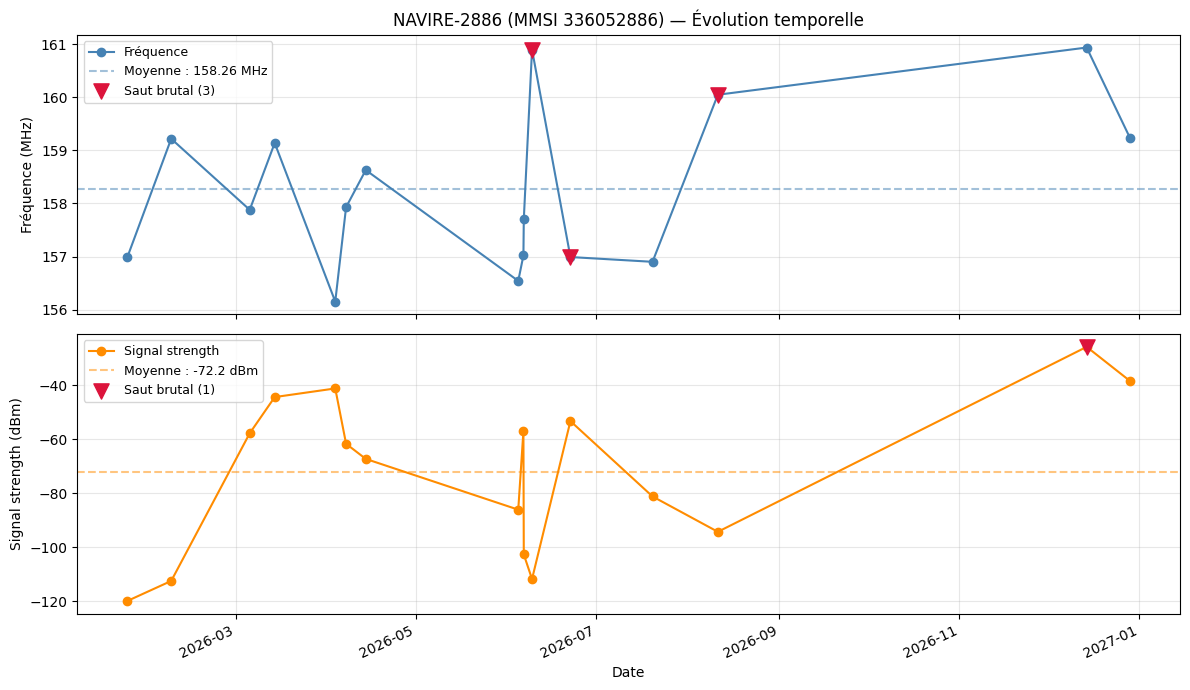

Graphique sauvegardé → q9_evolution_temporelle.png


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Fréquence ---
axes[0].plot(nav['timestamp'], nav['frequency'], 'o-',
             color='steelblue', linewidth=1.5, markersize=6, label='Fréquence')
axes[0].axhline(nav['frequency'].mean(), color='steelblue', linestyle='--',
                alpha=0.5, label=f'Moyenne : {nav["frequency"].mean():.2f} MHz')
# Marquer les sauts
freq_jumps = nav[nav['freq_jump']]
if len(freq_jumps):
    axes[0].scatter(freq_jumps['timestamp'], freq_jumps['frequency'],
                    color='crimson', s=120, zorder=5, marker='v',
                    label=f'Saut brutal ({len(freq_jumps)})')
axes[0].set_ylabel('Fréquence (MHz)')
axes[0].set_title(f'{ship_info["name"]} (MMSI {TARGET_MMSI}) — Évolution temporelle')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Signal Strength ---
axes[1].plot(nav['timestamp'], nav['signal_strength'], 'o-',
             color='darkorange', linewidth=1.5, markersize=6, label='Signal strength')
axes[1].axhline(nav['signal_strength'].mean(), color='darkorange', linestyle='--',
                alpha=0.5, label=f'Moyenne : {nav["signal_strength"].mean():.1f} dBm')
sig_jumps = nav[nav['sig_jump']]
if len(sig_jumps):
    axes[1].scatter(sig_jumps['timestamp'], sig_jumps['signal_strength'],
                    color='crimson', s=120, zorder=5, marker='v',
                    label=f'Saut brutal ({len(sig_jumps)})')
axes[1].set_ylabel('Signal strength (dBm)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/q9_evolution_temporelle.png', dpi=120)
plt.show()
print('Graphique sauvegardé → q9_evolution_temporelle.png')

### Analyse — Question 9

- Le MMSI de l'énoncé (`244710000`) est absent du dataset ; on utilise `336052886` — le navire avec le plus grand nombre de signatures (16).
- **Méthode de détection** : un changement est qualifié de brutal si la variation entre deux mesures consécutives dépasse **2σ** (deux fois l'écart-type de la série). Ce seuil est adaptatif par navire.
- Les triangles rouges ▼ signalent les instants de saut anormal — ils correspondent à des changements de fréquence ou de force de signal que l'on ne peut pas expliquer par une simple dérive naturelle de l'émetteur.
- Dans un contexte réel, un saut de fréquence brusque peut indiquer un **remplacement de l'émetteur radio** (changement d'identité technique) ou une **interférence/usurpation**.